### **Phase 1: Data Preparation and Exploratory Analysis (Revised)**

* **Data Loading:** Use `pandas.read_csv()` to load your dataset of 72 patients and 7,129 gene probes.
* **Binary Target Engineering:** Create a new binary target column. Map both `allB` and `allT` to `0` (representing ALL), and map `aml` to `1` (representing AML).
* **Standardization:** Apply `sklearn.preprocessing.StandardScaler` to the gene expression features to center the data (mean of 0) and scale it to unit variance (standard deviation of 1). *Note: Ensure you fit the scaler strictly on your training data to prevent data leakage, then transform both train and test sets.*
* **Dimensionality Reduction:** Fit `sklearn.decomposition.PCA` on the **scaled** data to compress the 7,129 features into 2 or 3 principal components.
* **Visualization:** Plot the PCA components using `matplotlib` or `seaborn`, coloring the points by the binary target (ALL vs. AML) to visually assess if the two main cancer types naturally separate in lower-dimensional space.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# plt.style.use('ggplot')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

In [45]:
raw_df = pd.read_csv("golub.csv", index_col=0).copy()
label_map = {"allB": 0, "allT": 0, "aml": 1}
raw_df["target"] = raw_df["cancer"].map(label_map)

metadata_cols = ["Samples", "BM.PB", "Gender", "Source", "tissue.mf", "cancer", "target"]
feature_cols = [column for column in raw_df.columns if column not in metadata_cols]
X = raw_df[feature_cols]
y = raw_df["target"]

print("Raw data shape:", raw_df.shape)
print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
raw_df[["cancer", "target"]].head()

# df = pd.read_csv("golub.csv").copy()
# df["target"] = df["cancer"].map({"allB": 0, "allT": 0, "aml": 1})
# df.head()
# # df = df.drop(columns=["Samples", "tissue.mf", "cancer"])
# # df.head()

Raw data shape: (72, 7135)
Feature matrix shape: (72, 7129)
Target distribution:
target
0    47
1    25
Name: count, dtype: int64


,cancer,target
Samples,,
39,allB,0
40,allB,0
42,allB,0
47,allB,0
48,allB,0


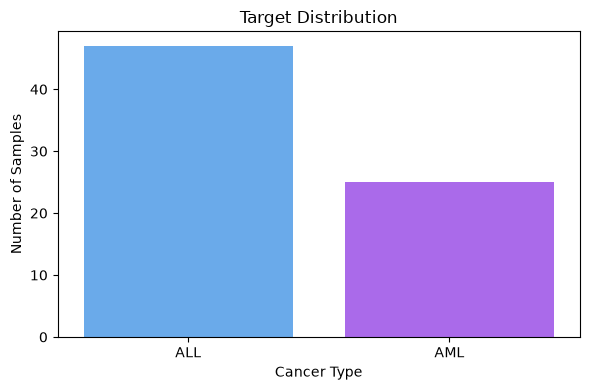

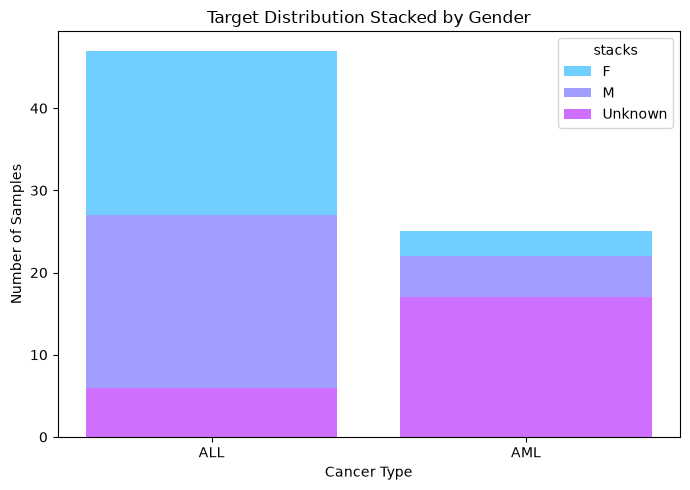

In [46]:
# Graph 1: target distribution
def plot_target_distribution(y):
    plt.figure(figsize=(6, 4))
    sns.countplot(
        x=y.map({0: "ALL", 1: "AML"}),
        hue=y.map({0: "ALL", 1: "AML"}),
        palette="cool",
        legend=False
    )
    plt.xlabel("Cancer Type")
    plt.ylabel("Number of Samples")
    plt.title("Target Distribution")
    plt.tight_layout()
    plt.show()

plot_target_distribution(y)


def plot_target_distribution_stacked(y, stacks, hue_labels):
    plot_df = pd.DataFrame({
        "target_label": y.map({0: "ALL", 1: "AML"}),
        "stacks": stacks.fillna("Unknown") if hasattr(stacks, "fillna") else stacks
    })

    plt.figure(figsize=(7, 5))
    ax = sns.histplot(
        data=plot_df,
        x="target_label",
        hue="stacks",
        multiple="stack",
        edgecolor="none",
        linewidth=0,
        shrink=0.8,
        palette="cool",
    )
    ax.set_xlabel("Cancer Type")
    ax.set_ylabel("Number of Samples")
    ax.set_title(f"Target Distribution Stacked by {hue_labels}")
    plt.tight_layout()
    plt.show()

plot_target_distribution_stacked(y, raw_df["Gender"], "Gender")

# # Graph 2: stacked bar chart
# plot_df = raw_df.copy()
# plot_df["target_label"] = plot_df["target"].map({0: "ALL", 1: "AML"})
# plot_df["Gender"] = plot_df["Gender"].fillna("Unknown")

# plt.figure(figsize=(7, 5))
# ax = sns.histplot(
#     data=plot_df,
#     x="target_label",
#     hue="Gender",
#     multiple="stack",
#     edgecolor="none",
#     linewidth=0,
#     shrink=0.8,
#     palette="cool",
# )
# ax.set_xlabel("Cancer Type")
# ax.set_ylabel("Number of Samples")
# ax.set_title("Target Distribution Stacked by Gender")
# plt.tight_layout()
# plt.show()

# # Graph 2: stacked bars with target on x-axis and stacks by gender
# plot_df = raw_df.copy()
# plot_df["target_label"] = plot_df["target"].map({0: "ALL", 1: "AML"})
# plot_df["Gender"] = plot_df["Gender"].fillna("Unknown")

# target_gender_counts = pd.crosstab(plot_df["target_label"], plot_df["Gender"])
# ax = target_gender_counts.plot(kind="bar", stacked=True, figsize=(7, 5), colormap="Set2")
# ax.set_xlabel("Cancer Type")
# ax.set_ylabel("Number of Samples")
# ax.set_title("Target Distribution Stacked by Gender")
# ax.legend(title="Gender")
# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()


In [47]:
# split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

# plot_target_distribution(y_train)
# plot_target_distribution(y_test)
# plot_target_distribution_stacked(y_train, raw_df.loc[y_train.index, "Gender"], "Gender (Training Set)")
# plot_target_distribution_stacked(y_test, raw_df.loc[y_test.index, "Gender"], "Gender (Testing Set)")

In [48]:
# scale the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


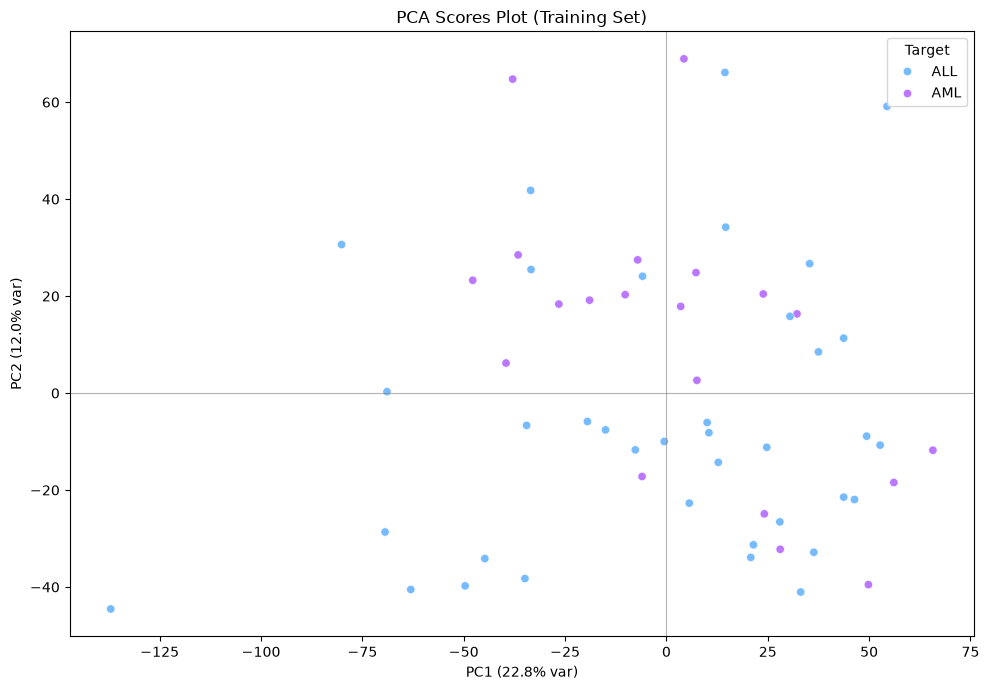

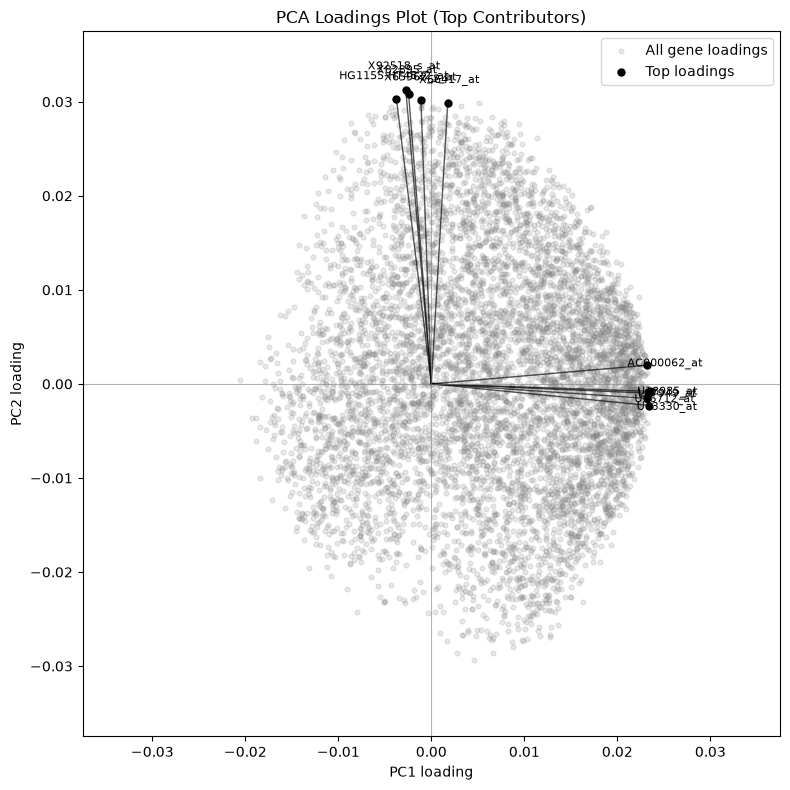

In [49]:
# run PCA on the training data
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

def plot_pca_two_views(scores, pca_model, y_labels, feature_names, top_per_pc=5):
    # Plot 1: sample scores in PC space
    plot_df = pd.DataFrame({
        "PC1": scores[:, 0],
        "PC2": scores[:, 1],
        "target": y_labels.map({0: "ALL", 1: "AML"}) if hasattr(y_labels, "map") else y_labels
    })

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.scatterplot(
        data=plot_df,
        x="PC1",
        y="PC2",
        hue="target",
        palette="cool",
        alpha=0.8,
        ax=ax
    )
    explained = pca_model.explained_variance_ratio_ * 100
    ax.set_xlabel(f"PC1 ({explained[0]:.1f}% var)")
    ax.set_ylabel(f"PC2 ({explained[1]:.1f}% var)")
    ax.set_title("PCA Scores Plot (Training Set)")
    ax.axhline(0, color="gray", linewidth=0.8, alpha=0.6)
    ax.axvline(0, color="gray", linewidth=0.8, alpha=0.6)
    ax.legend(title="Target")
    plt.tight_layout()
    plt.show()

    # Plot 2: loading vectors in PC space
    loadings = pca_model.components_.T
    idx_pc1 = np.argsort(np.abs(loadings[:, 0]))[-top_per_pc:]
    idx_pc2 = np.argsort(np.abs(loadings[:, 1]))[-top_per_pc:]
    top_idx = np.unique(np.concatenate([idx_pc1, idx_pc2]))

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(loadings[:, 0], loadings[:, 1], s=12, alpha=0.18, color="gray", label="All gene loadings")
    ax.scatter(loadings[top_idx, 0], loadings[top_idx, 1], s=25, color="black", label="Top loadings")

    for idx in top_idx:
        x_val, y_val = loadings[idx, 0], loadings[idx, 1]
        ax.plot([0, x_val], [0, y_val], color="black", alpha=0.65, linewidth=1)
        ax.text(x_val * 1.08, y_val * 1.08, feature_names[idx], fontsize=8, ha="center", va="center")

    lim = np.max(np.abs(loadings[:, :2])) * 1.2
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel("PC1 loading")
    ax.set_ylabel("PC2 loading")
    ax.set_title("PCA Loadings Plot (Top Contributors)")
    ax.axhline(0, color="gray", linewidth=0.8, alpha=0.6)
    ax.axvline(0, color="gray", linewidth=0.8, alpha=0.6)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_pca_two_views(
    scores=X_train_pca,
    pca_model=pca,
    y_labels=y_train,
    feature_names=feature_cols,
    top_per_pc=5
)

### **Phase 2: Statistical Significance (Control of False Discoveries)**

* **Univariate Analysis:** Since you now have two groups (ALL vs. AML), loop through all 7,129 genes and perform a two-sample statistical test for each (e.g., Welch's t-test using `scipy.stats.ttest_ind` with `equal_var=False`, or the non-parametric Mann-Whitney U test using `scipy.stats.mannwhitneyu`).
* **Multiple Testing Correction:** Extract the 7,129 p-values and pass them through `statsmodels.stats.multitest.multipletests` using `method='fdr_bh'` to compute the False Discovery Rate (FDR).
* **Baseline Output:** Save the list of genes that pass your FDR threshold (e.g., FDR < 0.05). This is your statistically significant baseline.

In [ ]:
# Separate the training data into ALL (0) and AML (1) groups
# y_train is a pandas Series, so we use its values to index the X_train NumPy array
X_train_ALL = X_train[y_train == 0]
X_train_AML = X_train[y_train == 1]

# Perform Univariate Analysis (Welch's t-test)
# We use equal_var=False because we cannot assume the variance of gene expression is identical between the ALL and AML groups. axis=0 runs the test across all columns (genes).
t_stats, p_values = ttest_ind(X_train_ALL, X_train_AML, equal_var=False, axis=0)

# Multiple Testing Correction (FDR using Benjamini-Hochberg)
# We set alpha to 0.05 to control the False Discovery Rate at 5%
reject_null, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

# Compile the results into a structured DataFrame for easy viewing
ttest_results = pd.DataFrame({
    'Gene_Probe': feature_cols,
    'T_Statistic': t_stats,
    'Raw_P_Value': p_values,
    'FDR_Corrected_P': pvals_corrected,
    'Is_Significant': reject_null
})

# Sort the genes from most to least significant
ttest_results = ttest_results.sort_values(by='FDR_Corrected_P', ascending=True)

# Extract the final baseline list of statistically significant genes
significant_genes = ttest_results[ttest_results['Is_Significant']]['Gene_Probe'].tolist()

# Output the detailed account of conclusions
print(f"--- Statistical Significance ---")
print(f"Total gene probes tested: {len(feature_cols)}")
print(f"Number of statistically significant genes (FDR < 0.05): {len(significant_genes)}")
print(f"Percentage of genes considered significant: {(len(significant_genes)/len(feature_cols))*100:.2f}%\n")

print("Top 5 most significant gene probes:")
print(ttest_results.head())



--- Phase 2: Statistical Significance ---
Total gene probes tested: 7129
Number of statistically significant genes (FDR < 0.05): 663
Percentage of genes considered significant: 9.30%

Top 5 most significant gene probes:
            Gene_Probe  T_Statistic   Raw_P_Value  FDR_Corrected_P  \
6280       M31211_s_at     7.761132  2.779597e-10     9.504358e-07   
4972         Y08612_at     7.618312  3.999589e-10     9.504358e-07   
2440         S50223_at     7.877414  1.389871e-10     9.504358e-07   
6854         M31523_at     8.049950  7.453702e-10     1.328436e-06   
6701  X97267_rna1_s_at     7.418268  1.484773e-09     2.116989e-06   

      Is_Significant  
6280            True  
4972            True  
2440            True  
6854            True  
6701            True  


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Separate the training data into ALL (0) and AML (1) groups
X_train_ALL = X_train[y_train == 0]
X_train_AML = X_train[y_train == 1]

# ==========================================
# TEST 1: Parametric (Welch's T-Test)
# ==========================================
# Run Welch's t-test across all genes simultaneously using axis=0
t_stats, p_values_t = ttest_ind(X_train_ALL, X_train_AML, equal_var=False, axis=0)

# Apply Benjamini-Hochberg FDR correction (alpha = 0.05)
reject_null_t, pvals_corrected_t, _, _ = multipletests(p_values_t, alpha=0.05, method='fdr_bh')

# Extract significant genes based on the t-test
sig_genes_t = [feature_cols[i] for i in range(len(feature_cols)) if reject_null_t[i]]


# ==========================================
# TEST 2: Non-Parametric (Mann-Whitney U Test)
# ==========================================
# We loop through each column (gene) because vectorization is less straightforward for this test
p_values_mw = np.zeros(X_train.shape[1])
for i in range(X_train.shape[1]):
    # alternative='two-sided' checks if the distributions are simply different, regardless of direction
    stat, p_val = mannwhitneyu(X_train_ALL[:, i], X_train_AML[:, i], alternative='two-sided')
    p_values_mw[i] = p_val

# Apply Benjamini-Hochberg FDR correction (alpha = 0.05)
reject_null_mw, pvals_corrected_mw, _, _ = multipletests(p_values_mw, alpha=0.05, method='fdr_bh')

# Extract significant genes based on the Mann-Whitney test
sig_genes_mw = [feature_cols[i] for i in range(len(feature_cols)) if reject_null_mw[i]]


# ==========================================
# SYNTHESIS & COMPARISON
# ==========================================
# Convert lists to Python sets to easily compute intersections and differences
set_t = set(sig_genes_t)
set_mw = set(sig_genes_mw)

# Find genes deemed significant by BOTH tests (highly robust baseline)
robust_baseline_genes = set_t.intersection(set_mw)

# Output the detailed account of conclusions
print("--- Statistical Significance (Control of False Discoveries) ---")
print(f"Total gene probes tested: {len(feature_cols)}")
print(f"Genes significant via Welch's T-Test (Parametric): {len(sig_genes_t)}")
print(f"Genes significant via Mann-Whitney U (Non-Parametric): {len(sig_genes_mw)}")
print(f"Genes significant in BOTH tests (Intersection): {len(robust_baseline_genes)}")

# Create a master DataFrame for your final report or further inspection
significance_results = pd.DataFrame({
    'Gene_Probe': feature_cols,
    'T_Test_Raw_P': p_values_t,
    'T_Test_FDR_P': pvals_corrected_t,
    'MW_Raw_P': p_values_mw,
    'MW_FDR_P': pvals_corrected_mw,
    'Sig_in_Both': [feature_cols[i] in robust_baseline_genes for i in range(len(feature_cols))]
})

--- Statistical Significance (Control of False Discoveries) ---
Total gene probes tested: 7129
Genes significant via Welch's T-Test (Parametric): 663
Genes significant via Mann-Whitney U (Non-Parametric): 744
Genes significant in BOTH tests (Intersection): 586


### **Phase 3: Classification and Variable Selection**

To handle high-dimensional collinear features ($p \gg n$) and extract a predictive biomarker subset, use L1 regularization.

* **Binary Lasso Regression:** Use `sklearn.linear_model.LogisticRegression` with `penalty='l1'` and `solver='liblinear'` or `'saga'`. This induces sparsity, shrinking the coefficients of irrelevant genes to zero.
* **Alternative (Linear SVM):** Use `sklearn.svm.LinearSVC` with `penalty='l1'` and `dual=False`.
* **Hyperparameter Tuning:** Use `sklearn.model_selection.GridSearchCV` with Stratified K-Fold cross-validation to find the optimal regularization parameter (`C`) that minimizes classification error while maintaining sparsity.

### **Phase 4: Variable Selection Stability (Core Requirement)**

You must explicitly document how multi-collinearity affects sparsity and compute true feature inclusion probabilities.

* **Bootstrapping:** Use `sklearn.utils.resample` to create $B$ bootstrap samples (e.g., $B=100$) of your training data.
* **Model Iteration:** Fit your optimally tuned L1 Logistic Regression (or SVM) on each bootstrap sample.
* **Stability Mapping:** For each run, record which genes have non-zero coefficients.
* **Inclusion Probabilities:** Calculate the proportion of times each gene was selected across the $B$ runs. A gene selected 95 out of 100 times has an inclusion probability of 0.95 (highly stable). Document how collinearity might cause some genes' probabilities to fluctuate.

### **Phase 5: Synthesis and Final Evaluation**

* **The Contrast:** Use Python sets to compare your statistically significant genes (from Phase 2) against the predictive biomarkers selected by your stable ML model (Phase 4).
* **Evaluation Metrics:** Evaluate the final model on a hidden test set based on three criteria:
    1. **Binary classification error** (Accuracy, F1-Score).
    2. **Sparsity** (the exact number of final selected genes).
    3. **Reproducibility/Stability score** (e.g., the average inclusion probability of your final biomarker subset).
* **Submission Formatting:** Your Python script must be error-free and shared via a notebook on Google Colab. Provide the link at the end of your PDF report. Ensure the notebook outputs a detailed explanation of your conclusions, not just raw numbers.